
# Análisis de moderación y captura de neutrones en el WCD (100000 neutrones)

Geometría de referencia de esta corrida:
- Neutrones inyectados desde **2 m** de altura (z = 200 cm) sobre el tanque, verticalmente hacia abajo.
- Tanque cilíndrico de **1.33 m** de altura (`z ≈ 133.124 cm` la superficie superior del agua), cuerpo en
  **acero inoxidable** (`G4_STAINLESS-STEEL`), revestido internamente con **Tyvek** (`Tyvek_HDPE`).
- PMT ubicado bajo la tapa interna, a **~26 cm** de profundidad.
- Medio detector: agua pura (`Water_TS_H_of_Water`) — para corridas con NaCl (2.5/5/10 %) el mismo
  notebook aplica cambiando la definición de `NUCLEOS_MEDIO_DETECTOR` (ver más abajo).

Archivos de entrada (en esta misma carpeta):
| Archivo | Contenido |
|---|---|
| `capturas-neutrones.tsv` | Solo los pasos con `step_process == nCapture` (evento de captura), cualquier material. |
| `neutrones-incidentes.tsv` | 1 fila por neutrón inyectado (los 100000): su primer paso, siempre en `Air`. |
| `pasos-neutrones.tsv` | Historial **completo** de pasos de cada neutrón (`Transportation`, `hadElastic`, `nCapture`, ...). |
| `interacciones-neutrones.tsv` | Igual que el anterior pero **sin** los pasos de `Transportation` (solo interacciones físicas). |

El identificador que permite encadenar un mismo neutrón entre los 4 archivos es `run_id`
(en estos archivos `event_id`, `track_id` y `parent_id` son constantes: cada neutrón primario
tiene su propio `run_id` único de 0 a 99999).

**Pipeline del notebook** (sigue los 4 pasos pedidos):
1. Filtrar `capturas-neutrones.tsv` a las capturas ocurridas en el medio detector (agua pura: núcleos H y O).
2. Verificar esas capturas contra `neutrones-incidentes.tsv` (neutrón realmente inyectado desde el inicio).
3. Extraer de `pasos-neutrones.tsv` el historial completo de esos neutrones, y de ahí el tramo
   "desde la primera `hadElastic` hasta la `nCapture`" (el ciclo de moderación).
4. Cruzar con `interacciones-neutrones.tsv` para corroborar ese ciclo y calcular:
   ξ (letargía logarítmica), P(N | captura, medio), coeficiente de captura, reflexión y transmisión,
   además de la dispersión previa en acero/Tyvek/aire antes de ingresar al agua.


## 0. Configuración: rutas, esquemas de columnas y utilidades

In [85]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 30)


def estilo_tabla(styler, titulo):
    '''Formato común (título, encabezado, alineación) para todas las tablas de resultados del notebook.'''
    return (
        styler
        .set_caption(titulo)
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold'),
                                               ('text-align', 'left'), ('padding-bottom', '6px')]},
            {'selector': 'th', 'props': [('text-align', 'left'), ('background-color', '#f0f0f0')]},
        ])
        .set_properties(**{'text-align': 'left'})
    )

# --- Rutas -------------------------------------------------------------
BASE_DIR = Path.cwd()  # ejecutar el notebook desde la carpeta que contiene los 4 .tsv

RUTA_CAPTURAS = BASE_DIR / 'capturas-neutrones.tsv'
RUTA_INCIDENTES = BASE_DIR / 'neutrones-incidentes.tsv'
RUTA_PASOS = BASE_DIR / 'pasos-neutrones.tsv'
RUTA_INTERACCIONES = BASE_DIR / 'interacciones-neutrones.tsv'

DIR_SALIDA = BASE_DIR / 'Salidas'
DIR_FIGURAS = DIR_SALIDA / 'figuras'
DIR_SALIDA.mkdir(exist_ok=True)
DIR_FIGURAS.mkdir(exist_ok=True)

for r in (RUTA_CAPTURAS, RUTA_INCIDENTES, RUTA_PASOS, RUTA_INTERACCIONES):
    assert r.exists(), f'No se encontró: {r}'

# --- Esquemas de columnas (los archivos traen una cabecera "# col1\tcol2...") ---
COLUMNAS_CAPTURAS = ['run_id', 'event_id', 'particle', 'track_id', 'parent_id', 'step_number',
                      'step_process', 'material', 'target_Z', 'target_A',
                      'pre_x_cm', 'pre_y_cm', 'pre_z_cm', 'post_x_cm', 'post_y_cm', 'post_z_cm',
                      'pre_energy_MeV', 'post_energy_MeV', 'global_time_ns']

COLUMNAS_PASOS = ['run_id', 'event_id', 'particle', 'track_id', 'parent_id', 'step_number',
                   'creator_process', 'step_process', 'material',
                   'pre_x_cm', 'pre_y_cm', 'pre_z_cm', 'post_x_cm', 'post_y_cm', 'post_z_cm',
                   'pre_energy_MeV', 'post_energy_MeV', 'global_time_ns']

DTYPES_CAPTURAS = {'particle': 'category', 'step_process': 'category', 'material': 'category',
                    'track_id': 'int32', 'parent_id': 'int32', 'step_number': 'int32',
                    'target_Z': 'int32', 'target_A': 'int32'}

DTYPES_PASOS = {'particle': 'category', 'creator_process': 'category', 'step_process': 'category',
                 'material': 'category', 'track_id': 'int32', 'parent_id': 'int32',
                 'step_number': 'int32'}


def cargar_tsv(ruta, columnas, dtypes):
    return pd.read_csv(ruta, sep='\t', skiprows=1, names=columnas, dtype=dtypes)


# Núcleos de captura que se consideran parte del "medio detector".
# Para esta corrida (agua pura) solo H (Z=1) y O (Z=8).
# Para corridas con NaCl, ampliar por ejemplo a {1: 'H', 8: 'O', 11: 'Na', 17: 'Cl'}.
NUCLEOS_MEDIO_DETECTOR = {1: 'H', 8: 'O'}

# Color y etiqueta legible fijos por material de estructura, consistentes en todo el notebook.
COLOR_MATERIAL = {
    'G4_STAINLESS-STEEL': '#4C72B0',
    'Tyvek_HDPE': '#DD8452',
    'Air': '#55A868',
}
ETIQUETA_MATERIAL = {
    'G4_STAINLESS-STEEL': 'Acero inoxidable',
    'Tyvek_HDPE': 'Tyvek',
    'Air': 'Aire',
}

print('Rutas OK. Salidas en:', DIR_SALIDA)


Rutas OK. Salidas en: /home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Nuevas-simulaciones-2026/25meV/Agua-pura-80H-PMT/Agua-pura-80H-PMT/Capturas/Archivos-capturas-neutrones/Salidas



## 1. Capturas en el medio detector (`capturas-neutrones.tsv`)

Cargamos todas las capturas (`nCapture`) registradas, revisamos en qué materiales ocurrieron y
nos quedamos solo con las que ocurrieron en agua pura sobre H u O (cualquier otro núcleo, p. ej.
Fe/Cr/Ni del acero, o N del aire, queda descartado de este subconjunto).


In [86]:

df_capturas = cargar_tsv(RUTA_CAPTURAS, COLUMNAS_CAPTURAS, DTYPES_CAPTURAS)
print(f'Total de eventos de captura (nCapture) registrados: {len(df_capturas):,}')

conteo_material = df_capturas['material'].value_counts()
tabla_material = pd.DataFrame({
    'Capturas': conteo_material,
    '% del total': conteo_material / len(df_capturas) * 100,
})
tabla_material.index.name = 'Material'

display(
    estilo_tabla(tabla_material.style,
                 f'Distribución de capturas por material — {len(df_capturas):,} eventos nCapture')
    .format({'Capturas': '{:,.0f}', '% del total': '{:.2f} %'})
    .bar(subset='% del total', color='#8fd19e', vmin=0, vmax=100)
)


Total de eventos de captura (nCapture) registrados: 22,748


,Capturas,% del total
Material,,
Water_TS_H_of_Water,"19,623",86.26 %
G4_STAINLESS-STEEL,"2,979",13.10 %
Air,81,0.36 %
Tyvek_HDPE,65,0.29 %


In [87]:

es_agua = df_capturas['material'].astype(str).str.contains('Water', na=False)

print('Capturas en material tipo "Water", por Z del núcleo objetivo:')
print(df_capturas.loc[es_agua, 'target_Z'].value_counts().sort_index())

es_nucleo_valido = df_capturas['target_Z'].isin(NUCLEOS_MEDIO_DETECTOR)

otros_en_agua = df_capturas.loc[es_agua & ~es_nucleo_valido]
if len(otros_en_agua):
    print(f'\nAtención: {len(otros_en_agua)} capturas en agua sobre núcleos NO esperados (revisar):')
    print(otros_en_agua['target_Z'].value_counts())
else:
    print('\nOK: todas las capturas en agua ocurren sobre los núcleos esperados '
          f'{list(NUCLEOS_MEDIO_DETECTOR.values())}.')

df_capturas_medio = df_capturas.loc[es_agua & es_nucleo_valido].copy()
assert df_capturas_medio['run_id'].is_unique, 'Un run_id no debería tener más de una captura'

print(f'\n>>> Neutrones capturados en el medio detector (agua pura): {len(df_capturas_medio):,}')

RUTA_SALIDA_1 = DIR_SALIDA / '01_capturas_medio_detector.tsv'
df_capturas_medio.to_csv(RUTA_SALIDA_1, sep='\t', index=False)
print(f'Guardado: {RUTA_SALIDA_1}')

df_capturas_medio.head()


Capturas en material tipo "Water", por Z del núcleo objetivo:
target_Z
1    19609
8       14
Name: count, dtype: int64

OK: todas las capturas en agua ocurren sobre los núcleos esperados ['H', 'O'].

>>> Neutrones capturados en el medio detector (agua pura): 19,623
Guardado: /home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Nuevas-simulaciones-2026/25meV/Agua-pura-80H-PMT/Agua-pura-80H-PMT/Capturas/Archivos-capturas-neutrones/Salidas/01_capturas_medio_detector.tsv


,run_id,event_id,particle,track_id,parent_id,step_number,step_process,material,target_Z,target_A,pre_x_cm,pre_y_cm,pre_z_cm,post_x_cm,post_y_cm,post_z_cm,pre_energy_MeV,post_energy_MeV,global_time_ns
0,1,0,neutron,1,0,239,nCapture,Water_TS_H_of_Water,1,1,3.276225,-26.861965,125.122623,3.098818,-26.965248,124.907633,1.000699e-07,0,591226.5330
1,5,0,neutron,1,0,24,nCapture,Water_TS_H_of_Water,1,1,30.436452,-17.161360,131.802090,30.444490,-17.148959,131.821914,4.056228e-09,0,331412.5922
2,8,0,neutron,1,0,10,nCapture,Water_TS_H_of_Water,1,1,-7.806806,16.386821,131.962728,-7.748481,16.145990,132.079218,4.986289e-08,0,313668.0601
3,10,0,neutron,1,0,123,nCapture,Water_TS_H_of_Water,1,1,-18.337666,38.231381,131.458885,-18.292812,38.214133,131.493328,1.899129e-08,0,464645.2788
4,21,0,neutron,1,0,163,nCapture,Water_TS_H_of_Water,1,1,3.826093,15.415198,126.781037,3.866313,15.436143,126.814198,4.540224e-08,0,500307.3577


In [88]:

# --- Tabla: capturas en el medio detector, por núcleo (H vs O) ---
conteo_nucleo = df_capturas_medio['target_Z'].value_counts().sort_index()

tabla_nucleos = pd.DataFrame({
    'Núcleo': [NUCLEOS_MEDIO_DETECTOR.get(z, f'Z={z}') for z in conteo_nucleo.index],
    'Capturas': conteo_nucleo.values,
}).set_index('Núcleo')
tabla_nucleos['% de las capturas en el medio'] = (
    tabla_nucleos['Capturas'] / tabla_nucleos['Capturas'].sum() * 100
)

display(
    estilo_tabla(
        tabla_nucleos.style,
        f'Capturas por núcleo en el medio detector — {len(df_capturas_medio):,} neutrones capturados'
    )
    .format({'Capturas': '{:,.0f}', '% de las capturas en el medio': '{:.2f} %'})
    .bar(subset='% de las capturas en el medio', color='#8fd19e', vmin=0, vmax=100)
)


,Capturas,% de las capturas en el medio
Núcleo,,
H,"19,609",99.93 %
O,14,0.07 %



## 2. Verificación contra los neutrones inyectados (`neutrones-incidentes.tsv`)

Este archivo tiene una fila por cada uno de los 100000 neutrones inyectados (su paso inicial,
siempre en `Air`, a 2 m de altura). Lo usamos para:
- confirmar que cada neutrón capturado en el medio efectivamente proviene de la inyección inicial
  (no es un artefacto de otro `run_id`), y
- anexar su información de inyección (posición/energía/tiempo iniciales) a la tabla de capturas.


In [89]:

df_incidentes = cargar_tsv(RUTA_INCIDENTES, COLUMNAS_PASOS, DTYPES_PASOS)
assert df_incidentes['run_id'].is_unique
print(f'Neutrones inyectados en total: {len(df_incidentes):,}')
assert set(df_incidentes['material'].unique()) == {'Air'}, 'Se esperaba que todos los registros de incidencia fueran en Air'

faltantes = set(df_capturas_medio['run_id']) - set(df_incidentes['run_id'])
assert not faltantes, f'{len(faltantes)} neutrones capturados en el medio no tienen registro de inyección'

df_paso2 = df_capturas_medio.merge(
    df_incidentes.add_suffix('_incidente').rename(columns={'run_id_incidente': 'run_id'}),
    on='run_id', how='inner', validate='one_to_one'
)
assert len(df_paso2) == len(df_capturas_medio)

print(f'>>> Neutrones capturados en el medio, verificados contra su inyección inicial: {len(df_paso2):,}')

RUTA_SALIDA_2 = DIR_SALIDA / '02_capturas_medio_verificadas_incidencia.tsv'
df_paso2.to_csv(RUTA_SALIDA_2, sep='\t', index=False)
print(f'Guardado: {RUTA_SALIDA_2}')

df_paso2.head()


Neutrones inyectados en total: 100,000
>>> Neutrones capturados en el medio, verificados contra su inyección inicial: 19,623
Guardado: /home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Nuevas-simulaciones-2026/25meV/Agua-pura-80H-PMT/Agua-pura-80H-PMT/Capturas/Archivos-capturas-neutrones/Salidas/02_capturas_medio_verificadas_incidencia.tsv


,run_id,event_id,particle,track_id,parent_id,step_number,step_process,material,target_Z,target_A,pre_x_cm,pre_y_cm,pre_z_cm,post_x_cm,post_y_cm,...,track_id_incidente,parent_id_incidente,step_number_incidente,creator_process_incidente,step_process_incidente,material_incidente,pre_x_cm_incidente,pre_y_cm_incidente,pre_z_cm_incidente,post_x_cm_incidente,post_y_cm_incidente,post_z_cm_incidente,pre_energy_MeV_incidente,post_energy_MeV_incidente,global_time_ns_incidente
0,1,0,neutron,1,0,239,nCapture,Water_TS_H_of_Water,1,1,3.276225,-26.861965,125.122623,3.098818,-26.965248,...,1,0,1,none,Transportation,Air,8.539714,-30.253346,200,8.539714,-30.253346,133.124,2.499996e-08,2.499996e-08,305793.6085
1,5,0,neutron,1,0,24,nCapture,Water_TS_H_of_Water,1,1,30.436452,-17.161360,131.802090,30.444490,-17.148959,...,1,0,1,none,Transportation,Air,29.166555,-17.502981,200,29.166555,-17.502981,133.124,2.499996e-08,2.499996e-08,305793.6085
2,8,0,neutron,1,0,10,nCapture,Water_TS_H_of_Water,1,1,-7.806806,16.386821,131.962728,-7.748481,16.145990,...,1,0,1,none,Transportation,Air,-7.422464,16.271550,200,-7.422464,16.271550,133.124,2.499996e-08,2.499996e-08,305793.6085
3,10,0,neutron,1,0,123,nCapture,Water_TS_H_of_Water,1,1,-18.337666,38.231381,131.458885,-18.292812,38.214133,...,1,0,1,none,Transportation,Air,-16.941484,31.588999,200,-16.941484,31.588999,133.124,2.499996e-08,2.499996e-08,305793.6085
4,21,0,neutron,1,0,163,nCapture,Water_TS_H_of_Water,1,1,3.826093,15.415198,126.781037,3.866313,15.436143,...,1,0,1,none,Transportation,Air,-0.312040,18.306025,200,-0.312040,18.306025,133.124,2.499996e-08,2.499996e-08,305793.6085



## 3. Historial completo de pasos (`pasos-neutrones.tsv`) y ciclo de dispersión → captura

Filtramos `pasos-neutrones.tsv` (historial completo, incluye `Transportation`) a los `run_id`
capturados en el medio, y guardamos ese subconjunto completo. Luego, por cada neutrón, recortamos
su secuencia de pasos para quedarnos **solo** con el tramo que va desde su **primera `hadElastic`**
hasta la **`nCapture`** final (mismas columnas que el archivo original).


In [90]:

run_ids_medio = set(df_capturas_medio['run_id'])

df_pasos = cargar_tsv(RUTA_PASOS, COLUMNAS_PASOS, DTYPES_PASOS)
print(f'Total de pasos registrados (todos los neutrones, todos los procesos): {len(df_pasos):,}')
assert set(df_pasos['run_id'].unique()) == set(df_incidentes['run_id'].unique())

df_pasos_capturados = (
    df_pasos[df_pasos['run_id'].isin(run_ids_medio)]
    .sort_values(['run_id', 'step_number'])
    .copy()
)
print(f'Neutrones cubiertos: {df_pasos_capturados["run_id"].nunique():,} | '
      f'Filas (pasos) totales: {len(df_pasos_capturados):,}')

RUTA_SALIDA_3A = DIR_SALIDA / '03a_pasos_completos_capturados_medio.tsv'
df_pasos_capturados.to_csv(RUTA_SALIDA_3A, sep='\t', index=False)
print(f'Guardado: {RUTA_SALIDA_3A}')


Total de pasos registrados (todos los neutrones, todos los procesos): 3,843,486
Neutrones cubiertos: 19,623 | Filas (pasos) totales: 1,855,424
Guardado: /home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Nuevas-simulaciones-2026/25meV/Agua-pura-80H-PMT/Agua-pura-80H-PMT/Capturas/Archivos-capturas-neutrones/Salidas/03a_pasos_completos_capturados_medio.tsv


In [91]:

# Para cada neutrón (run_id) nos quedamos con el tramo de filas que va desde su
# PRIMERA colisión hadElastic hasta su fila nCapture (ambas inclusive). Si un neutrón
# se captura sin ninguna hadElastic previa, el tramo es solo la fila de captura (N=0).
df_pos = df_pasos_capturados.reset_index(drop=True)
df_pos['_pos'] = df_pos.index

pos_captura = (
    df_pos.loc[df_pos['step_process'] == 'nCapture']
    .groupby('run_id')['_pos'].first()
)
assert set(pos_captura.index) == run_ids_medio, 'Falta la fila de captura de algún neutrón del medio'

pos_primer_elastico = (
    df_pos.loc[df_pos['step_process'] == 'hadElastic']
    .groupby('run_id')['_pos'].min()
)

info_recorte = pd.DataFrame({'pos_fin': pos_captura})
info_recorte['pos_inicio'] = pos_primer_elastico.reindex(info_recorte.index).fillna(info_recorte['pos_fin']).astype(int)

mascara = np.zeros(len(df_pos), dtype=bool)
for pos_inicio, pos_fin in zip(info_recorte['pos_inicio'], info_recorte['pos_fin']):
    mascara[pos_inicio:pos_fin + 1] = True

df_ciclo_dispersion = df_pos.loc[mascara].drop(columns='_pos').copy()

print(f'>>> Neutrones con ciclo dispersión->captura extraído: {df_ciclo_dispersion["run_id"].nunique():,}')
print(f'>>> Filas totales del ciclo recortado: {len(df_ciclo_dispersion):,}')

RUTA_SALIDA_3B = DIR_SALIDA / '03b_ciclo_dispersion_hasta_captura.tsv'
df_ciclo_dispersion.to_csv(RUTA_SALIDA_3B, sep='\t', index=False)
print(f'Guardado: {RUTA_SALIDA_3B}')

df_ciclo_dispersion.head(10)


>>> Neutrones con ciclo dispersión->captura extraído: 19,623
>>> Filas totales del ciclo recortado: 1,798,082
Guardado: /home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Nuevas-simulaciones-2026/25meV/Agua-pura-80H-PMT/Agua-pura-80H-PMT/Capturas/Archivos-capturas-neutrones/Salidas/03b_ciclo_dispersion_hasta_captura.tsv


,run_id,event_id,particle,track_id,parent_id,step_number,creator_process,step_process,material,pre_x_cm,pre_y_cm,pre_z_cm,post_x_cm,post_y_cm,post_z_cm,pre_energy_MeV,post_energy_MeV,global_time_ns
3,1,0,neutron,1,0,4,none,hadElastic,Water_TS_H_of_Water,8.539714,-30.253346,133.062000,8.539714,-30.253346,132.608489,2.499996e-08,2.383429e-08,308150.8053
4,1,0,neutron,1,0,5,none,hadElastic,Water_TS_H_of_Water,8.539714,-30.253346,132.608489,8.080680,-30.696614,132.419635,2.383429e-08,2.351995e-08,311267.2696
5,1,0,neutron,1,0,6,none,hadElastic,Water_TS_H_of_Water,8.080680,-30.696614,132.419635,8.040702,-30.789805,132.444674,2.351995e-08,2.924772e-08,311759.6725
6,1,0,neutron,1,0,7,none,hadElastic,Water_TS_H_of_Water,8.040702,-30.789805,132.444674,7.952917,-30.909251,132.327071,2.924772e-08,2.905771e-08,312559.5927
7,1,0,neutron,1,0,8,none,hadElastic,Water_TS_H_of_Water,7.952917,-30.909251,132.327071,7.669621,-31.150170,132.335409,2.905771e-08,2.684756e-08,314137.2599
8,1,0,neutron,1,0,9,none,hadElastic,Water_TS_H_of_Water,7.669621,-31.150170,132.335409,7.132916,-31.330703,132.001921,2.684756e-08,2.661296e-08,317036.9146
9,1,0,neutron,1,0,10,none,hadElastic,Water_TS_H_of_Water,7.132916,-31.330703,132.001921,7.178019,-31.341546,131.929856,2.661296e-08,1.932005e-08,317416.7401
10,1,0,neutron,1,0,11,none,hadElastic,Water_TS_H_of_Water,7.178019,-31.341546,131.929856,7.196176,-31.393713,131.912953,1.932005e-08,2.394131e-08,317717.2006
11,1,0,neutron,1,0,12,none,hadElastic,Water_TS_H_of_Water,7.196176,-31.393713,131.912953,7.211104,-31.294317,132.040483,2.394131e-08,3.451106e-08,318475.9146
12,1,0,neutron,1,0,13,none,hadElastic,Water_TS_H_of_Water,7.211104,-31.294317,132.040483,7.361048,-31.498886,131.782683,3.451106e-08,3.251402e-08,319883.3897



## 4. Corroboración con `interacciones-neutrones.tsv`

`interacciones-neutrones.tsv` es el mismo historial pero sin los pasos de `Transportation`
(solo `hadElastic`, `nCapture`, `neutronInelastic`). Lo usamos para:
- generar el archivo final de interacciones de los neutrones capturados en el medio, y
- corroborar (comparar) el número de dispersiones elásticas y la energía por colisión obtenidos
  en el paso 3 a partir de `pasos-neutrones.tsv`.


In [92]:

df_interacciones = cargar_tsv(RUTA_INTERACCIONES, COLUMNAS_PASOS, DTYPES_PASOS)
print(f'Total de interacciones registradas (sin Transportation): {len(df_interacciones):,}')

conteo_step_process = df_interacciones['step_process'].value_counts()
tabla_step_process = pd.DataFrame({
    'Interacciones': conteo_step_process,
    '% del total': conteo_step_process / len(df_interacciones) * 100,
})
tabla_step_process.index.name = 'step_process'

display(
    estilo_tabla(tabla_step_process.style,
                 f'Interacciones por tipo de proceso — {len(df_interacciones):,} filas')
    .format({'Interacciones': '{:,.0f}', '% del total': '{:.2f} %'})
    .bar(subset='% del total', color='#8fd19e', vmin=0, vmax=100)
)

df_interacciones_capturados = (
    df_interacciones[df_interacciones['run_id'].isin(run_ids_medio)]
    .sort_values(['run_id', 'step_number'])
    .copy()
)
print(f'\nInteracciones de los {df_interacciones_capturados["run_id"].nunique():,} neutrones '
      f'capturados en el medio: {len(df_interacciones_capturados):,} filas')

RUTA_SALIDA_4 = DIR_SALIDA / '04_interacciones_capturados_medio.tsv'
df_interacciones_capturados.to_csv(RUTA_SALIDA_4, sep='\t', index=False)
print(f'Guardado: {RUTA_SALIDA_4}')


Total de interacciones registradas (sin Transportation): 3,243,996


,Interacciones,% del total
step_process,,
hadElastic,"3,219,440",99.24 %
nCapture,"22,748",0.70 %
neutronInelastic,"1,808",0.06 %



Interacciones de los 19,623 neutrones capturados en el medio: 1,793,463 filas
Guardado: /home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Nuevas-simulaciones-2026/25meV/Agua-pura-80H-PMT/Agua-pura-80H-PMT/Capturas/Archivos-capturas-neutrones/Salidas/04_interacciones_capturados_medio.tsv


In [93]:

def dispersiones_y_xi(df):
    '''N (dispersiones hadElastic) por run_id y xi = ln(E_pre/E_post) por colisión.'''
    hadElastic = df[df['step_process'] == 'hadElastic']
    n_por_neutron = hadElastic.groupby('run_id').size()
    n_por_neutron = n_por_neutron.reindex(sorted(run_ids_medio), fill_value=0)
    xi = np.log(hadElastic['pre_energy_MeV'] / hadElastic['post_energy_MeV'])
    xi = xi.replace([np.inf, -np.inf], np.nan).dropna()
    return n_por_neutron, xi


N_desde_pasos, xi_desde_pasos = dispersiones_y_xi(df_ciclo_dispersion)
N_desde_interacciones, xi_desde_interacciones = dispersiones_y_xi(df_interacciones_capturados)

diferencia_max_N = (N_desde_pasos - N_desde_interacciones).abs().max()
print(f'Máxima diferencia en N entre pasos-neutrones e interacciones-neutrones: {diferencia_max_N}')
print(f'ξ̄ calculado desde pasos-neutrones.tsv:         {xi_desde_pasos.mean():.5f}')
print(f'ξ̄ calculado desde interacciones-neutrones.tsv: {xi_desde_interacciones.mean():.5f}')

assert diferencia_max_N == 0, 'El número de dispersiones no coincide entre ambos archivos'

# A partir de aquí usamos interacciones-neutrones.tsv (archivo del paso 4) como fuente canónica.
N_captura = N_desde_interacciones
xi_colisiones = xi_desde_interacciones


Máxima diferencia en N entre pasos-neutrones e interacciones-neutrones: 0
ξ̄ calculado desde pasos-neutrones.tsv:         -0.00111
ξ̄ calculado desde interacciones-neutrones.tsv: -0.00111



## 5. Balance global: captura (medio / estructura), reflexión y transmisión

Clasificamos los **100000** neutrones inyectados en cuatro categorías mutuamente excluyentes:

- **Capturado en el medio (H/O)**: está en `run_ids_medio` (paso 1).
- **Capturado en otro material**: aparece en `capturas-neutrones.tsv` pero no en agua sobre H/O
  (p. ej. acero, Tyvek, N del aire).
- **Transmitido**: no fue capturado, pero sí tocó alguna vez material `Water` (entró al medio y salió).
- **Reflejado**: no fue capturado y nunca tocó material `Water` (regresó hacia la región de
  incidencia sin llegar a ingresar al medio detector).


In [94]:

material_captura = df_capturas.set_index('run_id')['material']

run_ids_entraron_agua = set(
    df_interacciones.loc[
        df_interacciones['material'].astype(str).str.contains('Water', na=False), 'run_id'
    ].unique()
)

df_clasificacion = pd.DataFrame({'run_id': sorted(df_incidentes['run_id'].unique())})
df_clasificacion['material_captura'] = df_clasificacion['run_id'].map(material_captura)
df_clasificacion['entro_al_agua'] = df_clasificacion['run_id'].isin(run_ids_entraron_agua)

condiciones = [
    df_clasificacion['run_id'].isin(run_ids_medio),
    df_clasificacion['material_captura'].notna(),
    df_clasificacion['entro_al_agua'],
]
categorias = ['Capturado en el medio (H/O)', 'Capturado en otro material', 'Transmitido']
df_clasificacion['categoria'] = np.select(condiciones, categorias, default='Reflejado')

RUTA_SALIDA_5 = DIR_SALIDA / '05_clasificacion_captura_reflexion_transmision.tsv'
df_clasificacion.to_csv(RUTA_SALIDA_5, sep='\t', index=False)
print(f'Guardado: {RUTA_SALIDA_5}')

conteo = df_clasificacion['categoria'].value_counts()
fraccion = conteo / len(df_clasificacion)
assert np.isclose(fraccion.sum(), 1.0)

orden_categorias = ['Capturado en el medio (H/O)', 'Transmitido', 'Reflejado', 'Capturado en otro material']

tabla_balance = pd.DataFrame({
    'Neutrones': conteo.reindex(orden_categorias),
    '% del total': fraccion.reindex(orden_categorias) * 100,
})
tabla_balance.index.name = 'Categoría'

display(
    estilo_tabla(tabla_balance.style, f'Balance global — {len(df_clasificacion):,} neutrones inyectados')
    .format({'Neutrones': '{:,.0f}', '% del total': '{:.2f} %'})
    .bar(subset='% del total', color='#8fd19e', vmin=0, vmax=100)
)


Guardado: /home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Nuevas-simulaciones-2026/25meV/Agua-pura-80H-PMT/Agua-pura-80H-PMT/Capturas/Archivos-capturas-neutrones/Salidas/05_clasificacion_captura_reflexion_transmision.tsv


,Neutrones,% del total
Categoría,,
Capturado en el medio (H/O),"19,623",19.62 %
Transmitido,"71,950",71.95 %
Reflejado,"5,302",5.30 %
Capturado en otro material,"3,125",3.12 %


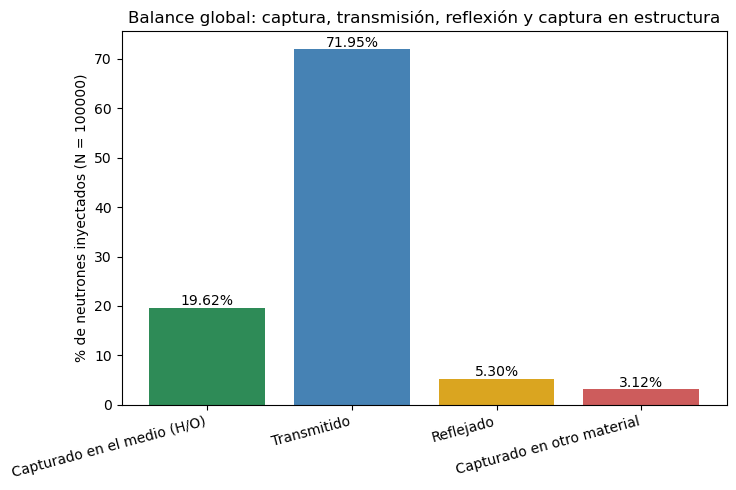

In [95]:

orden = ['Capturado en el medio (H/O)', 'Transmitido', 'Reflejado', 'Capturado en otro material']
valores = [fraccion.get(c, 0.0) * 100 for c in orden]
colores = ['seagreen', 'steelblue', 'goldenrod', 'indianred']

fig, ax = plt.subplots(figsize=(7.5, 5))
barras = ax.bar(orden, valores, color=colores)
ax.set_ylabel('% de neutrones inyectados (N = 100000)')
ax.set_title('Balance global: captura, transmisión, reflexión y captura en estructura')
for barra, v in zip(barras, valores):
    ax.text(barra.get_x() + barra.get_width() / 2, v + 0.5, f'{v:.2f}%', ha='center')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
fig.tight_layout()
fig.savefig(DIR_FIGURAS / '05_balance_captura_reflexion_transmision.png', dpi=150)
plt.show()



## 6. Moderación: letargía logarítmica ξ y P(N | captura, medio)

ξ = ln(E_pre / E_post) evaluado en cada colisión `hadElastic` de los neutrones capturados en el
medio (todas las colisiones de todos esos neutrones, agrupadas). Valores negativos son físicamente
válidos (up-scattering térmico, tratamiento S(α,β) para H ligado en agua).

N = número de colisiones `hadElastic` que experimentó cada neutrón antes de ser capturado.


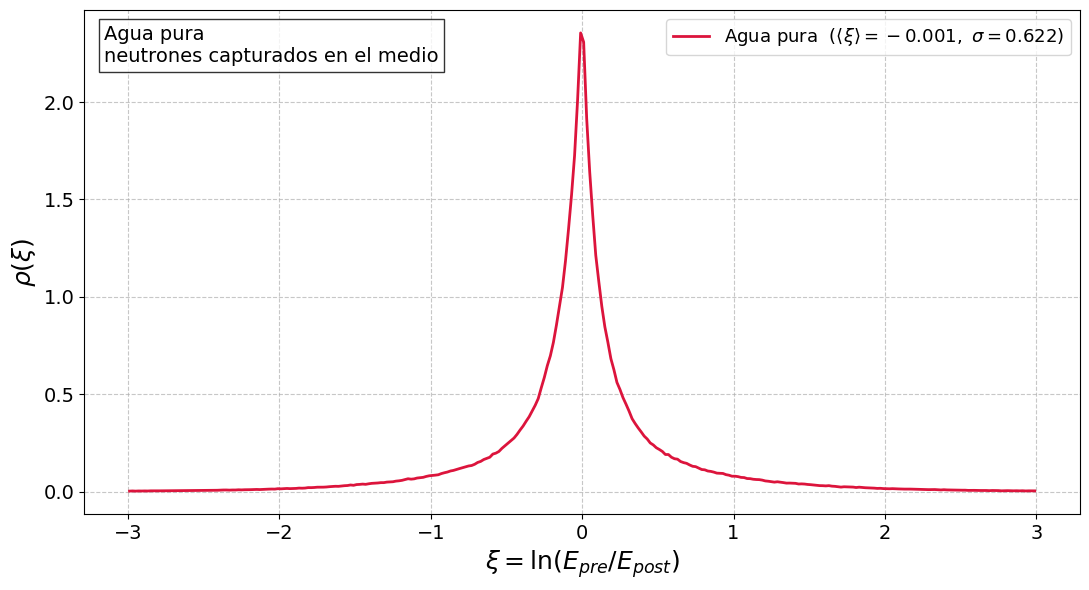

Número de colisiones hadElastic analizadas: 1,773,840
<ξ> = -0.00111 | σ = 0.62198
Colisiones fuera del rango graficado (-3.0, 3.0) (incluidas en las estadísticas, no en la curva): 0.373 %


In [96]:

# Curva de densidad (PDF) de xi, al estilo de las figuras de la tesis: histograma
# normalizado, convertido a línea sobre los centros de bin, con <xi> y sigma en la leyenda.
xi_valido = xi_colisiones.replace([np.inf, -np.inf], np.nan).dropna().to_numpy()

mean_xi = xi_valido.mean()
std_xi = xi_valido.std()

N_BINS_XI = 300
RANGO_XI = (-3.0, 3.0)  # fijo: el grueso de la distribución cae en +-1, una cola rara
                         # (up/down-scattering extremo a muy baja energía) se sale de este
                         # rango y no se dibuja, aunque sí cuenta en las estadísticas (mean/std)
frac_fuera_rango = np.mean((xi_valido < RANGO_XI[0]) | (xi_valido > RANGO_XI[1]))

counts, bin_edges = np.histogram(xi_valido, bins=N_BINS_XI, range=RANGO_XI, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(bin_centers, counts, linewidth=2, color='crimson',
        label=rf'Agua pura  ($\langle\xi\rangle={mean_xi:.3f},\ \sigma={std_xi:.3f}$)')

ax.set_xlabel(r'$\xi = \ln(E_{pre}/E_{post})$', fontsize=18)
ax.set_ylabel(r'$\rho(\xi)$', fontsize=18)
ax.grid(True, linestyle='--', alpha=0.7)
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=13)
ax.text(
    0.02, 0.97, 'Agua pura\nneutrones capturados en el medio',
    transform=ax.transAxes, fontsize=14, verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

fig.tight_layout()
fig.savefig(DIR_FIGURAS / '06a_xi_letargia.png', dpi=300)
fig.savefig(DIR_FIGURAS / '06a_xi_letargia.pdf')
plt.show()

print(f'Número de colisiones hadElastic analizadas: {len(xi_valido):,}')
print(f'<ξ> = {mean_xi:.5f} | σ = {std_xi:.5f}')
print(f'Colisiones fuera del rango graficado {RANGO_XI} (incluidas en las estadísticas, '
      f'no en la curva): {frac_fuera_rango*100:.3f} %')


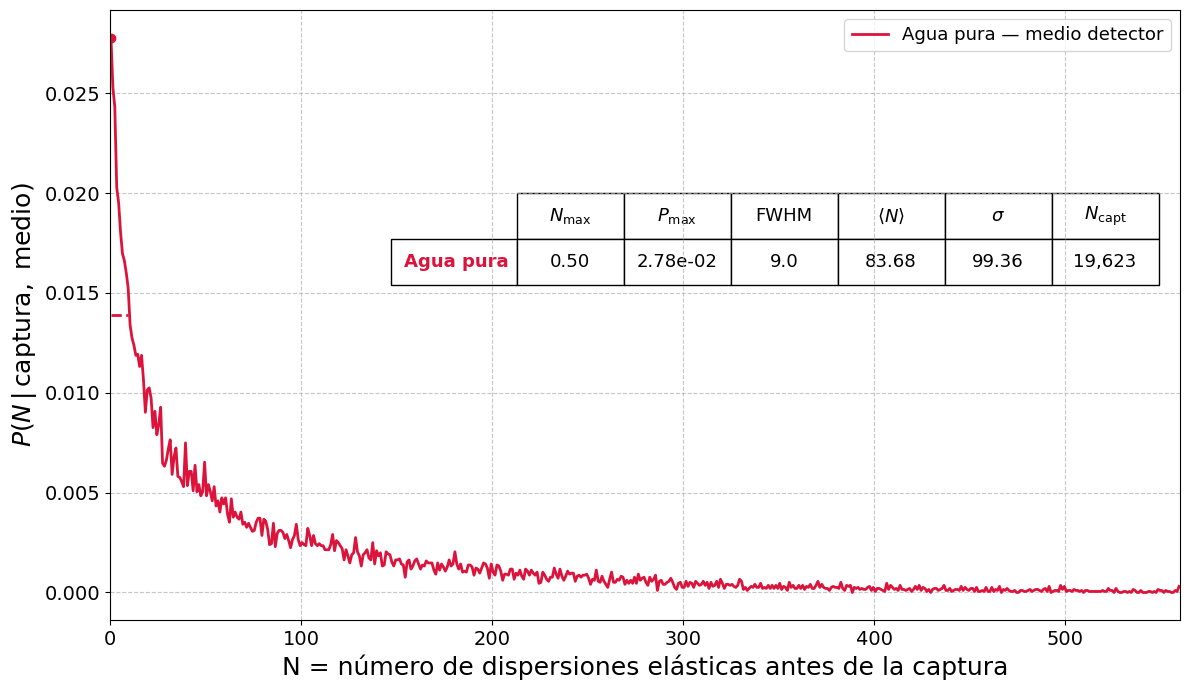

Rango graficado: [0, 560] -> 1.00 % de los neutrones capturados tiene N mayor a ese límite (fuera de la curva/tabla, sí incluido abajo).
N medio de dispersiones antes de la captura (todos los datos): 90.40
N mediana: 46 | percentil 95: 322 | percentil 99: 560 | máximo: 1598


In [97]:

# Estilo de las figuras comparativas por energía de la tesis: curva (no barras) +
# máximo refinado por ajuste parabólico + FWHM marcado + tabla resumen de resultados.
# Aquí solo hay una serie (este medio/energía), pero las funciones quedan listas para
# superponer más series (otras concentraciones de NaCl, otras energías) si se necesita:
# basta con llamar `curva_N_con_pico_y_fwhm` una vez por serie sobre el mismo `ax`.

def posicion_pico_refinado(bin_centers, counts):
    '''Ajusta una parábola a los 3 puntos alrededor del máximo para refinar su posición.'''
    idx = np.argmax(counts)
    if idx == 0 or idx == len(counts) - 1:
        return bin_centers[idx]
    x = bin_centers[idx - 1:idx + 2]
    y = counts[idx - 1:idx + 2]
    a, b, c = np.polyfit(x, y, 2)
    if abs(a) < 1e-12:  # 3 puntos casi colineales: el ajuste no refina nada útil
        return bin_centers[idx]
    return -b / (2 * a)


def curva_N_con_pico_y_fwhm(ax, datos, n_capturas, color, etiqueta, n_bins, rango):
    '''Dibuja P(N | captura, medio) como curva, marca el máximo refinado y el FWHM.
    Devuelve (x_max, y_max, FWHM, <N>, sigma) calculados sobre el histograma graficado.'''
    counts, bordes = np.histogram(datos, bins=n_bins, range=rango)
    centros = 0.5 * (bordes[:-1] + bordes[1:])
    counts_norm = counts / n_capturas  # bin de ancho 1 -> equivale a density=True

    ax.plot(centros, counts_norm, color=color, linewidth=2, label=etiqueta)

    N_mean = np.sum(centros * counts_norm)
    sigma = np.sqrt(np.sum((centros - N_mean) ** 2 * counts_norm))

    idx_max = np.argmax(counts_norm)
    y_max = counts_norm[idx_max]
    x_max = posicion_pico_refinado(centros, counts_norm)

    half_max = y_max / 2
    indices = np.where(counts_norm >= half_max)[0]
    x_left, x_right = centros[indices[0]], centros[indices[-1]]
    fwhm = x_right - x_left

    ax.plot(x_max, y_max, 'o', color=color)
    ax.hlines(half_max, x_left, x_right, colors=color, linestyles='dashed', linewidth=2)

    return x_max, y_max, fwhm, N_mean, sigma


n_valores = N_captura.values
max_n = int(n_valores.max())
p95 = np.percentile(n_valores, 95)

# Rango de graficado hasta el percentil 99 (redondeado a la decena) para no diluir el
# pico con la cola larga; el <N> impreso al final sí usa TODOS los datos, sin recortar.
N_MAX_PLOT = int(np.ceil(np.percentile(n_valores, 99) / 10) * 10)
frac_fuera_plot = np.mean(n_valores > N_MAX_PLOT)

fig, ax = plt.subplots(figsize=(12, 7))

x_max, y_max, fwhm, N_mean_hist, sigma_hist = curva_N_con_pico_y_fwhm(
    ax, n_valores, len(n_valores), 'crimson', 'Agua pura — medio detector',
    n_bins=N_MAX_PLOT, rango=(0, N_MAX_PLOT)
)

ax.set_xlabel('N = número de dispersiones elásticas antes de la captura', fontsize=18)
ax.set_ylabel(r'$P(N\,|\,\mathrm{captura,\ medio})$', fontsize=18)
ax.set_xlim(0, N_MAX_PLOT)
ax.grid(True, linestyle='--', alpha=0.7)
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=13)

# --- Tabla resumen (misma estructura que las figuras comparativas por energía) ---
fila = [f'{x_max:.2f}', f'{y_max:.2e}', f'{fwhm:.1f}', f'{N_mean_hist:.2f}',
        f'{sigma_hist:.2f}', f'{len(n_valores):,}']
tabla = ax.table(
    cellText=[fila],
    rowLabels=['Agua pura'],
    colLabels=[r'$N_{\max}$', r'$P_{\max}$', 'FWHM', r'$\langle N \rangle$',
               r'$\sigma$', r'$N_{\mathrm{capt}}$'],
    bbox=[0.38, 0.55, 0.60, 0.15],
    colLoc='center', cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(13)
for (fila_idx, col), celda in tabla.get_celld().items():
    if col == -1:
        celda.set_text_props(color='crimson', weight='bold')

fig.tight_layout()
fig.savefig(DIR_FIGURAS / '06b_P_N_captura.png', dpi=300)
fig.savefig(DIR_FIGURAS / '06b_P_N_captura.pdf')
plt.show()

print(f'Rango graficado: [0, {N_MAX_PLOT}] -> {frac_fuera_plot*100:.2f} % de los neutrones '
      f'capturados tiene N mayor a ese límite (fuera de la curva/tabla, sí incluido abajo).')
print(f'N medio de dispersiones antes de la captura (todos los datos): {n_valores.mean():.2f}')
print(f'N mediana: {np.median(n_valores):.0f} | percentil 95: {p95:.0f} | percentil 99: '
      f'{np.percentile(n_valores, 99):.0f} | máximo: {max_n}')



## 7. Dispersión previa al ingreso: acero, Tyvek y aire

Para **todos** los neutrones (no solo los capturados), se identifica el primer paso en el que
cada uno toca material `Water` (si existe) y se cuentan las colisiones `hadElastic` que ocurren
**antes** de ese instante (o durante todo su recorrido, si nunca llega a entrar), por material.
Esto caracteriza cuánto "rebotan" los neutrones en el acero inoxidable, el Tyvek y el aire antes
de alcanzar el medio detector.


In [98]:

df_inter_sorted = df_interacciones.sort_values(['run_id', 'step_number'])

primer_paso_agua = (
    df_inter_sorted.loc[df_inter_sorted['material'].astype(str).str.contains('Water', na=False)]
    .groupby('run_id')['step_number'].min()
    .rename('step_number_entrada_agua')
)

df_inter_sorted = df_inter_sorted.merge(primer_paso_agua, on='run_id', how='left')

antes_de_entrar = df_inter_sorted[
    df_inter_sorted['step_number_entrada_agua'].isna()
    | (df_inter_sorted['step_number'] < df_inter_sorted['step_number_entrada_agua'])
]

dispersiones_previas = antes_de_entrar[antes_de_entrar['step_process'] == 'hadElastic']
TOTAL_INYECTADOS = len(df_incidentes)

# --- Tabla A: colisiones hadElastic previas al ingreso, por material ---
conteo_colisiones = dispersiones_previas['material'].value_counts()
tabla_colisiones_previas = pd.DataFrame({
    'Material': [ETIQUETA_MATERIAL.get(m, m) for m in conteo_colisiones.index],
    'Colisiones hadElastic': conteo_colisiones.values,
}).set_index('Material')

display(
    estilo_tabla(tabla_colisiones_previas.style,
                 'Colisiones hadElastic antes de ingresar al agua, por material')
    .format({'Colisiones hadElastic': '{:,.0f}'})
)

# --- Tabla B: neutrones que dispersan >=1 vez en cada material, antes de ingresar ---
conteo_por_neutron = (
    dispersiones_previas.groupby(['run_id', 'material'], observed=True)
    .size()
    .unstack(fill_value=0)
)

neutrones_con_dispersion = (conteo_por_neutron > 0).sum()
tabla_neutrones_previos = pd.DataFrame({
    'Material': [ETIQUETA_MATERIAL.get(m, m) for m in neutrones_con_dispersion.index],
    'Neutrones': neutrones_con_dispersion.values,
}).set_index('Material')
tabla_neutrones_previos['% de los 100000 inyectados'] = (
    tabla_neutrones_previos['Neutrones'] / TOTAL_INYECTADOS * 100
)

display(
    estilo_tabla(tabla_neutrones_previos.style,
                 f'Neutrones (de {TOTAL_INYECTADOS:,}) que dispersan ≥1 vez en cada material antes de ingresar')
    .format({'Neutrones': '{:,.0f}', '% de los 100000 inyectados': '{:.2f} %'})
    .bar(subset='% de los 100000 inyectados', color='#8fd19e', vmin=0, vmax=100)
)

RUTA_SALIDA_7 = DIR_SALIDA / '07_dispersion_previa_ingreso_agua.tsv'
conteo_por_neutron.to_csv(RUTA_SALIDA_7, sep='\t')
print(f'Guardado: {RUTA_SALIDA_7}')


,Colisiones hadElastic
Material,
Acero inoxidable,"4,773"
Aire,"3,743"
Tyvek,"3,284"
Water_TS_H_of_Water,0


,Neutrones,% de los 100000 inyectados
Material,,
Aire,"3,386",3.39 %
Acero inoxidable,"4,374",4.37 %
Tyvek,"3,074",3.07 %


Guardado: /home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Nuevas-simulaciones-2026/25meV/Agua-pura-80H-PMT/Agua-pura-80H-PMT/Capturas/Archivos-capturas-neutrones/Salidas/07_dispersion_previa_ingreso_agua.tsv


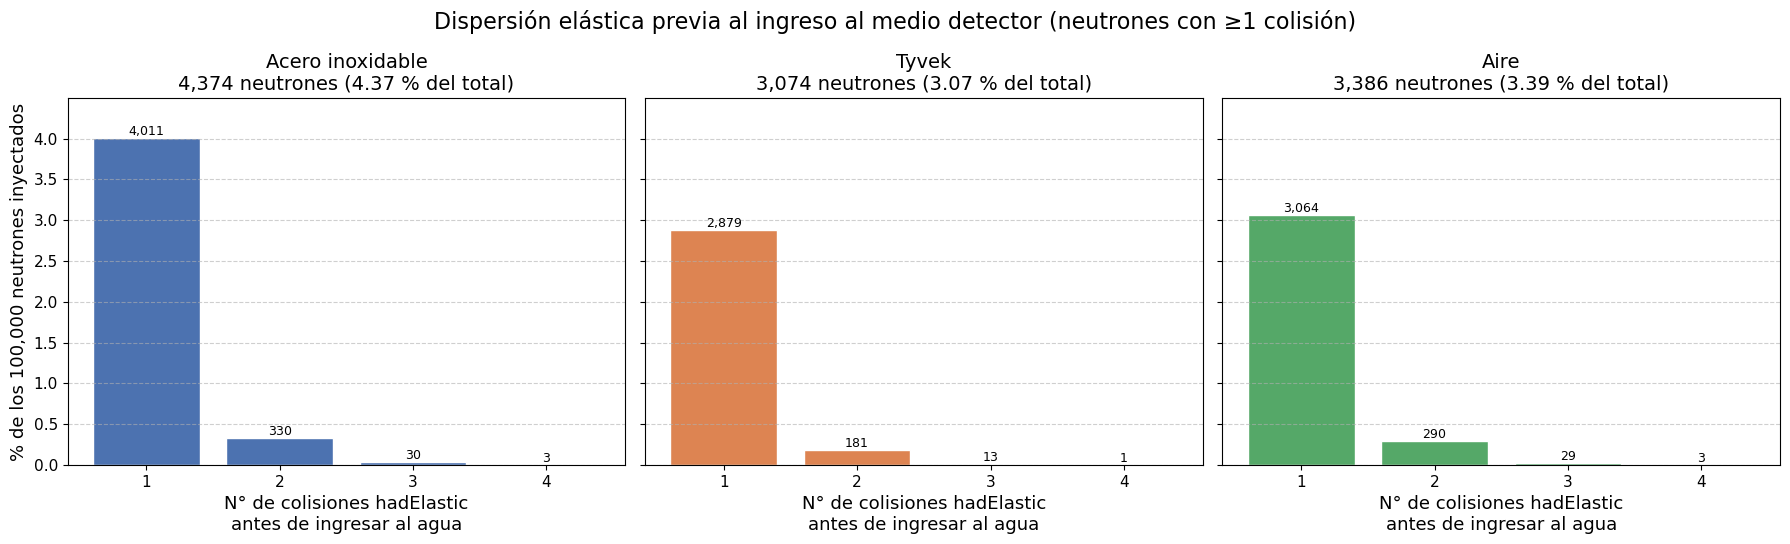

In [99]:

materiales_previos = [m for m in ['G4_STAINLESS-STEEL', 'Tyvek_HDPE', 'Air'] if m in conteo_por_neutron.columns]

fig, axes = plt.subplots(1, len(materiales_previos), figsize=(6.0 * len(materiales_previos), 5.5), sharey=True)
if len(materiales_previos) == 1:
    axes = [axes]

for ax, mat in zip(axes, materiales_previos):
    color = COLOR_MATERIAL.get(mat, 'slategray')
    etiqueta = ETIQUETA_MATERIAL.get(mat, mat)

    datos = conteo_por_neutron[mat]
    datos = datos[datos > 0]
    if len(datos) == 0:
        ax.set_title(f'{etiqueta}\n(sin dispersiones previas)', fontsize=14)
        continue

    conteo_n = datos.value_counts().sort_index()
    porcentaje = conteo_n / TOTAL_INYECTADOS * 100

    barras = ax.bar(conteo_n.index, porcentaje.values, color=color, edgecolor='white', width=0.8)
    for barra, n_neutrones in zip(barras, conteo_n.values):
        ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height(),
                f'{n_neutrones:,}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(conteo_n.index)
    ax.set_title(f'{etiqueta}\n{len(datos):,} neutrones ({len(datos) / TOTAL_INYECTADOS * 100:.2f} % del total)',
                 fontsize=14)
    ax.set_xlabel('N° de colisiones hadElastic\nantes de ingresar al agua', fontsize=13)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', labelsize=11)
    ax.margins(y=0.12)  # deja espacio para las etiquetas de conteo sobre las barras

axes[0].set_ylabel(f'% de los {TOTAL_INYECTADOS:,} neutrones inyectados', fontsize=13)

fig.suptitle('Dispersión elástica previa al ingreso al medio detector (neutrones con ≥1 colisión)', fontsize=16)
fig.tight_layout()
fig.savefig(DIR_FIGURAS / '07_dispersion_previa_ingreso.png', dpi=300)
fig.savefig(DIR_FIGURAS / '07_dispersion_previa_ingreso.pdf')
plt.show()



## 8. Tiempo hasta la captura

Δt = tiempo transcurrido entre la **primera dispersión elástica** de cada neutrón y su
**captura**, tomado de `global_time_ns` en `03b_ciclo_dispersion_hasta_captura.tsv` (mismo
tramo usado para N y ξ). Físicamente es la curva de "die-away" térmico: en un medio
moderador-absorbente, la población de neutrones térmicos decae con el tiempo como
$N(t) \propto e^{-t/\tau}$, con $\tau$ el tiempo de decaimiento (ligado a la sección eficaz de
absorción del medio — la cantidad de interés en sondas de neutrones para humedad/salinidad de
suelo). Un histograma en escala log-lineal (log en el eje de conteos) se ve como una línea recta
si la distribución es efectivamente exponencial, lo que permite verificar el modelo a simple vista
y ajustar $\tau$ por regresión.


In [100]:

# --- Δt por neutrón: primera hadElastic -> nCapture (mismo tramo que N y ξ) ---
tiempos_ciclo = df_ciclo_dispersion.groupby('run_id')['global_time_ns'].agg(['min', 'max'])
dt_captura_ns = (tiempos_ciclo['max'] - tiempos_ciclo['min']).rename('dt_captura_ns')
dt_captura_us = dt_captura_ns / 1000.0  # ns -> µs, más legible

frac_dt_cero = (dt_captura_us == 0).mean()
print(f'Neutrones capturados sin ninguna hadElastic previa (Δt = 0, N = 0): {frac_dt_cero * 100:.2f} %')

# --- Versión estricta: tiempo SOLO dentro del agua (desde que entra hasta la captura) ---
# Misma definición de "entrada al agua" que en el paso 7 (primera fila con material tipo
# Water en interacciones-neutrones.tsv), pero aquí tomamos su global_time_ns en vez del step_number.
t_entrada_agua_ns = (
    df_interacciones.loc[df_interacciones['material'].astype(str).str.contains('Water', na=False)]
    .groupby('run_id')['global_time_ns'].min()
)

dt_en_agua_ns = (tiempos_ciclo['max'] - t_entrada_agua_ns.reindex(tiempos_ciclo.index)).rename('dt_en_agua_ns')
assert dt_en_agua_ns.notna().all(), 'Todo neutrón capturado en el medio debió haber entrado al agua'
dt_en_agua_us = dt_en_agua_ns / 1000.0

frac_con_tiempo_previo = ((dt_captura_ns - dt_en_agua_ns) > 0).mean()
print(f'Neutrones cuyo Δt total incluye tiempo antes de entrar al agua '
      f'(1ª hadElastic en Tyvek/acero/aire): {frac_con_tiempo_previo * 100:.2f} %')

RUTA_SALIDA_8 = DIR_SALIDA / '08_tiempo_hasta_captura.tsv'
pd.concat([dt_captura_ns, dt_en_agua_ns], axis=1).reset_index().to_csv(RUTA_SALIDA_8, sep='\t', index=False)
print(f'Guardado: {RUTA_SALIDA_8}')


Neutrones capturados sin ninguna hadElastic previa (Δt = 0, N = 0): 2.78 %
Neutrones cuyo Δt total incluye tiempo antes de entrar al agua (1ª hadElastic en Tyvek/acero/aire): 4.62 %
Guardado: /home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Nuevas-simulaciones-2026/25meV/Agua-pura-80H-PMT/Agua-pura-80H-PMT/Capturas/Archivos-capturas-neutrones/Salidas/08_tiempo_hasta_captura.tsv


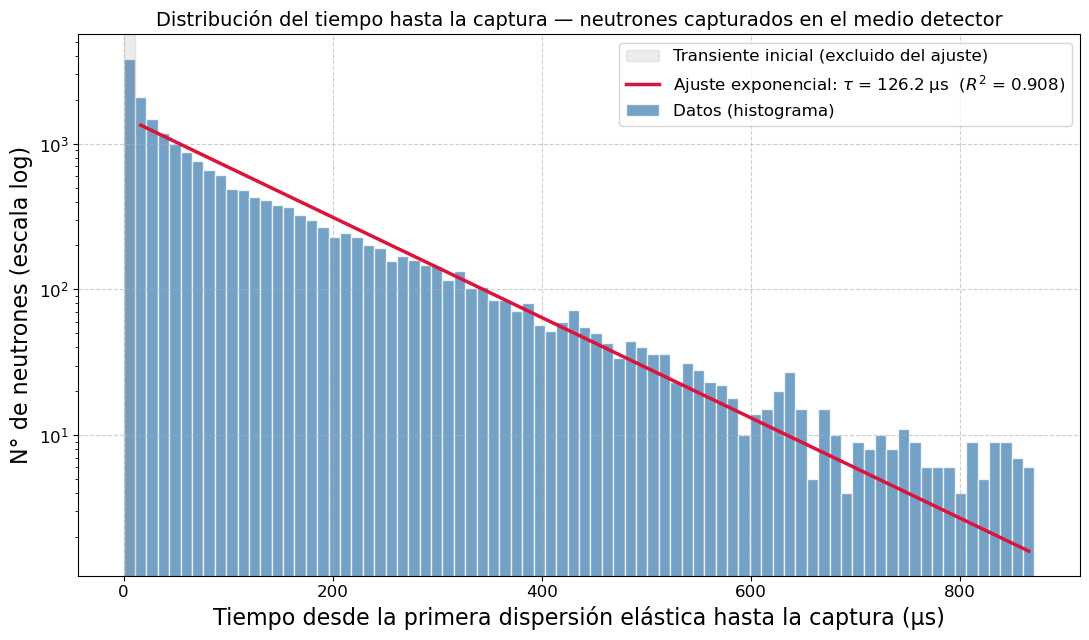

Rango graficado/ajustado: [0, 871] µs -> incluye el 99.50 % de los neutrones capturados en el medio.


In [101]:

# --- Histograma (log-lineal) + ajuste exponencial N(t) = N0 * exp(-t/tau) ---
LIM_T_US = np.percentile(dt_captura_us, 99.5)  # recorta la cola extrema para graficar/ajustar
dt_us_plot = dt_captura_us[dt_captura_us <= LIM_T_US].values

N_BINS_T = 80
counts, bordes = np.histogram(dt_us_plot, bins=N_BINS_T, range=(0, LIM_T_US))
centros = 0.5 * (bordes[:-1] + bordes[1:])
ancho_bin = bordes[1] - bordes[0]

# El primer bin concentra las capturas casi instantáneas (N=0 o una sola hadElastic) y queda
# muy por encima de la tendencia exponencial del resto -> es un transiente inicial, no parte
# del régimen de "die-away" térmico asintótico. Se excluye SOLO del ajuste (se sigue graficando).
UMBRAL_INICIO_AJUSTE_US = bordes[1]
mask_fit = (counts > 0) & (centros >= UMBRAL_INICIO_AJUSTE_US)

# Regresión lineal de ln(counts) vs t, ponderada por sqrt(counts) (más peso a los bines con
# mejor estadística). Pendiente = -1/tau.
pendiente, intercepto = np.polyfit(centros[mask_fit], np.log(counts[mask_fit]), 1,
                                    w=np.sqrt(counts[mask_fit]))
tau_us = -1 / pendiente
N0_fit = np.exp(intercepto)

log_pred = intercepto + pendiente * centros[mask_fit]
log_obs = np.log(counts[mask_fit])
ss_res = np.sum((log_obs - log_pred) ** 2)
ss_tot = np.sum((log_obs - log_obs.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.bar(centros, counts, width=ancho_bin, color='steelblue', alpha=0.75,
       edgecolor='white', label='Datos (histograma)')
ax.axvspan(0, UMBRAL_INICIO_AJUSTE_US, color='grey', alpha=0.15,
           label='Transiente inicial (excluido del ajuste)')
t_ajuste = centros[centros >= UMBRAL_INICIO_AJUSTE_US]
ax.plot(t_ajuste, N0_fit * np.exp(pendiente * t_ajuste), color='crimson', linewidth=2.5,
        label=rf'Ajuste exponencial: $\tau$ = {tau_us:.1f} µs  ($R^2$ = {r2:.3f})')

ax.set_yscale('log')
ax.set_xlabel('Tiempo desde la primera dispersión elástica hasta la captura (µs)', fontsize=16)
ax.set_ylabel('N° de neutrones (escala log)', fontsize=16)
ax.set_title('Distribución del tiempo hasta la captura — neutrones capturados en el medio detector',
             fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig(DIR_FIGURAS / '08_tiempo_hasta_captura.png', dpi=300)
fig.savefig(DIR_FIGURAS / '08_tiempo_hasta_captura.pdf')
plt.show()

print(f'Rango graficado/ajustado: [0, {LIM_T_US:.0f}] µs -> incluye el '
      f'{(dt_captura_us <= LIM_T_US).mean() * 100:.2f} % de los neutrones capturados en el medio.')


In [102]:

media_dt_us = dt_captura_us.mean()
std_dt_us = dt_captura_us.std()

tabla_tiempo = pd.DataFrame({
    'Valor': [
        media_dt_us,
        std_dt_us,
        dt_captura_us.median(),
        float(np.percentile(dt_captura_us, 95)),
        dt_captura_us.max(),
        tau_us,
        r2,
    ],
}, index=[
    '⟨Δt⟩ — tiempo medio hasta la captura (µs)',
    'σ — desviación estándar de Δt (µs)',
    'Mediana de Δt (µs)',
    'Percentil 95 de Δt (µs)',
    'Máximo Δt (µs)',
    'τ — tiempo de decaimiento ajustado (µs)',
    'R² del ajuste exponencial',
])

display(
    estilo_tabla(tabla_tiempo.style, 'Tiempo hasta la captura — neutrones capturados en el medio detector')
    .format({'Valor': '{:.3f}'})
)


,Valor
⟨Δt⟩ — tiempo medio hasta la captura (µs),114.636
σ — desviación estándar de Δt (µs),160.081
Mediana de Δt (µs),57.292
Percentil 95 de Δt (µs),412.222
Máximo Δt (µs),5187.447
τ — tiempo de decaimiento ajustado (µs),126.151
R² del ajuste exponencial,0.908



### Histograma con media y desviación estándar

Cálculo directo de $\langle \Delta t \rangle$ (promedio) y $\sigma$ (desviación estándar) sobre
**todos** los neutrones capturados en el medio, marcados sobre el histograma de Δt.


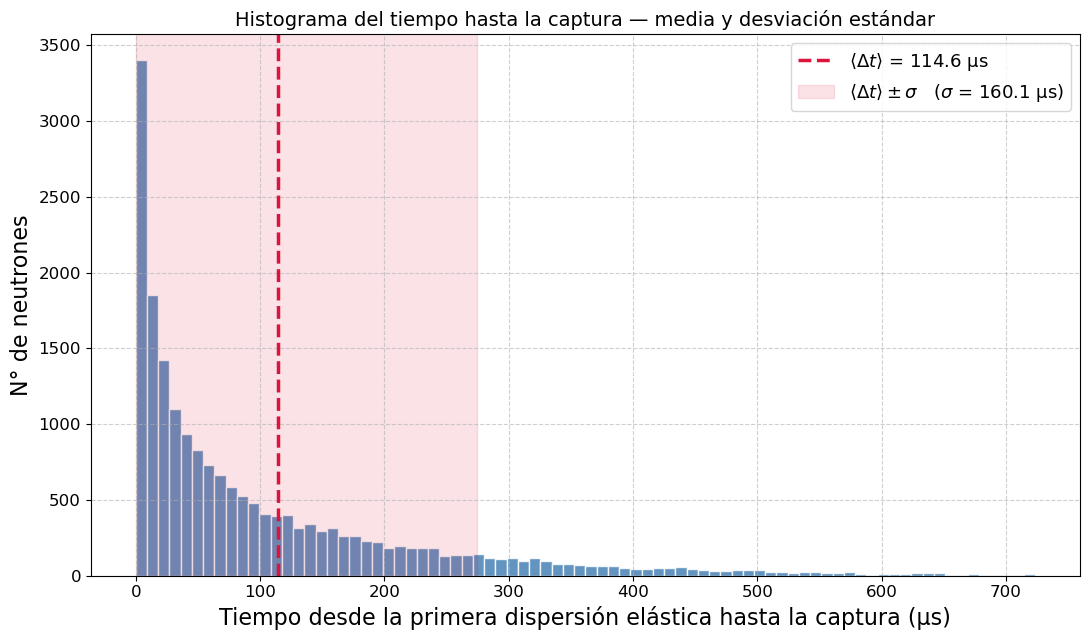

⟨Δt⟩ = 114.64 µs | σ = 160.08 µs (calculados sobre los 19,623 neutrones capturados en el medio, sin recortar)
Rango graficado: [0, 725] µs -> incluye el 99.00 % de esos neutrones


In [103]:

LIM_HIST_US = np.percentile(dt_captura_us, 99)  # recorta la cola extrema solo para visualizar
dt_us_hist = dt_captura_us[dt_captura_us <= LIM_HIST_US]

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.hist(dt_us_hist, bins=80, color='steelblue', edgecolor='white', alpha=0.85)

ax.axvline(media_dt_us, color='crimson', linewidth=2.5, linestyle='--',
           label=rf'$\langle \Delta t \rangle$ = {media_dt_us:.1f} µs')
ax.axvspan(max(media_dt_us - std_dt_us, 0), media_dt_us + std_dt_us, color='crimson', alpha=0.12,
           label=rf'$\langle \Delta t \rangle \pm \sigma$   ($\sigma$ = {std_dt_us:.1f} µs)')

ax.set_xlabel('Tiempo desde la primera dispersión elástica hasta la captura (µs)', fontsize=16)
ax.set_ylabel('N° de neutrones', fontsize=16)
ax.set_title('Histograma del tiempo hasta la captura — media y desviación estándar', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=13)

fig.tight_layout()
fig.savefig(DIR_FIGURAS / '08b_tiempo_captura_media_std.png', dpi=300)
fig.savefig(DIR_FIGURAS / '08b_tiempo_captura_media_std.pdf')
plt.show()

print(f'⟨Δt⟩ = {media_dt_us:.2f} µs | σ = {std_dt_us:.2f} µs (calculados sobre los '
      f'{len(dt_captura_us):,} neutrones capturados en el medio, sin recortar)')
print(f'Rango graficado: [0, {LIM_HIST_US:.0f}] µs -> incluye el '
      f'{(dt_captura_us <= LIM_HIST_US).mean() * 100:.2f} % de esos neutrones')



### Versión estricta: tiempo medido solo dentro del agua

El Δt anterior se mide desde la **primera dispersión elástica** del neutrón, sin importar el
material (para el 95.4 % de los neutrones capturados en el medio esa primera colisión ya ocurre
en agua, pero para el 4.6 % restante ocurre antes, en Tyvek/acero/aire). Aquí se calcula la
versión estricta: Δt_agua = tiempo desde que el neutrón **entra al agua** (mismo criterio de
"entrada" del paso 7, primera interacción con material `Water` en `interacciones-neutrones.tsv`)
hasta su captura.


In [104]:

media_dt_agua_us = dt_en_agua_us.mean()
std_dt_agua_us = dt_en_agua_us.std()

tabla_comparacion_dt = pd.DataFrame({
    'Δt total (desde 1ª hadElastic)': [
        media_dt_us, std_dt_us, dt_captura_us.median(),
        float(np.percentile(dt_captura_us, 95)), dt_captura_us.max(),
    ],
    'Δt en agua (desde la entrada)': [
        media_dt_agua_us, std_dt_agua_us, dt_en_agua_us.median(),
        float(np.percentile(dt_en_agua_us, 95)), dt_en_agua_us.max(),
    ],
}, index=['⟨Δt⟩ (µs)', 'σ (µs)', 'Mediana (µs)', 'Percentil 95 (µs)', 'Máximo (µs)']).T

display(
    estilo_tabla(tabla_comparacion_dt.style, 'Δt total vs. Δt estrictamente en agua')
    .format('{:.3f}')
)


,⟨Δt⟩ (µs),σ (µs),Mediana (µs),Percentil 95 (µs),Máximo (µs)
Δt total (desde 1ª hadElastic),114.636,160.081,57.292,412.222,5187.447
Δt en agua (desde la entrada),113.254,159.135,56.344,406.935,5187.447


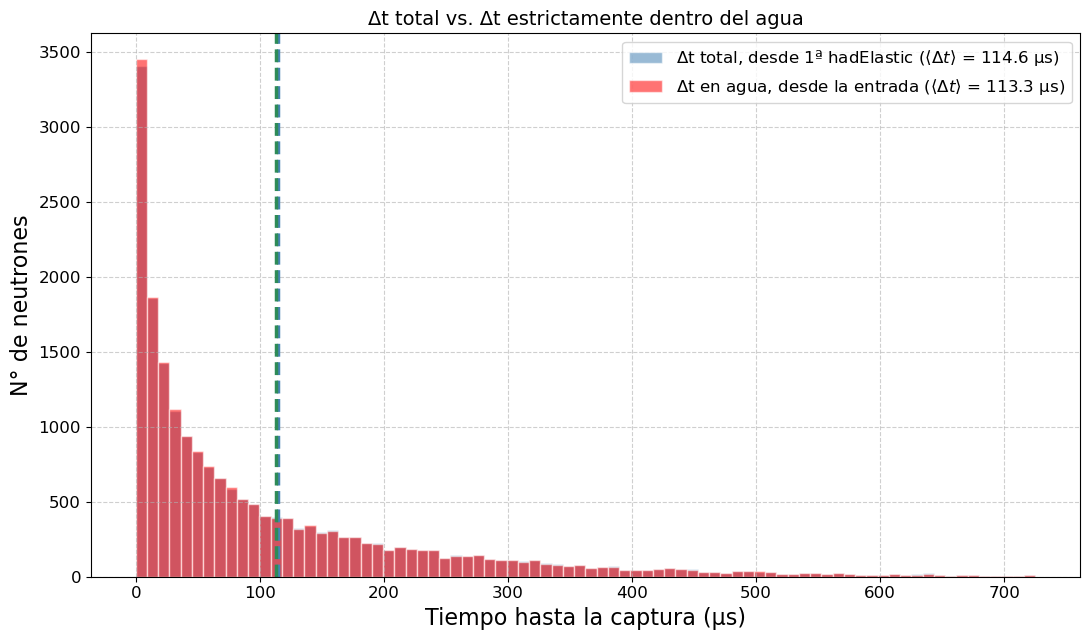

⟨Δt_agua⟩ = 113.25 µs | σ = 159.13 µs (vs. ⟨Δt_total⟩ = 114.64 µs -> diferencia de 1.22 %)


In [107]:

bins_comunes = np.linspace(0, LIM_HIST_US, 81)
dt_en_agua_hist = dt_en_agua_us[dt_en_agua_us <= LIM_HIST_US]

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.hist(dt_us_hist, bins=bins_comunes, color='steelblue', alpha=0.55, edgecolor='white',
        label=rf'Δt total, desde 1ª hadElastic ($\langle\Delta t\rangle$ = {media_dt_us:.1f} µs)')
ax.hist(dt_en_agua_hist, bins=bins_comunes, color='red', alpha=0.55, edgecolor='white',
        label=rf'Δt en agua, desde la entrada ($\langle\Delta t\rangle$ = {media_dt_agua_us:.1f} µs)')

ax.axvline(media_dt_us, color='steelblue', linewidth=2.5, linestyle='--')
ax.axvline(media_dt_agua_us, color='seagreen', linewidth=2.5, linestyle='--')

ax.set_xlabel('Tiempo hasta la captura (µs)', fontsize=16)
ax.set_ylabel('N° de neutrones', fontsize=16)
ax.set_title('Δt total vs. Δt estrictamente dentro del agua', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig(DIR_FIGURAS / '08c_tiempo_total_vs_en_agua.png', dpi=300)
fig.savefig(DIR_FIGURAS / '08c_tiempo_total_vs_en_agua.pdf')
plt.show()

print(f'⟨Δt_agua⟩ = {media_dt_agua_us:.2f} µs | σ = {std_dt_agua_us:.2f} µs '
      f'(vs. ⟨Δt_total⟩ = {media_dt_us:.2f} µs -> diferencia de '
      f'{(media_dt_us - media_dt_agua_us) / media_dt_agua_us * 100:.2f} %)')



## 9. Resumen final


In [106]:

# El balance global (captura/reflexión/transmisión) ya se muestra como tabla en el paso 5;
# aquí solo se resume la moderación y el listado de archivos generados.

# --- Tabla 1: moderación (letargía y número de dispersiones) ---
tabla_moderacion = pd.DataFrame({
    'Valor': [
        xi_valido.mean(),
        n_valores.mean(),
        float(np.median(n_valores)),
        float(np.percentile(n_valores, 95)),
    ],
}, index=[
    'ξ̄ — letargía logarítmica media por colisión',
    '⟨N⟩ — dispersiones elásticas medias antes de la captura',
    'Mediana de N',
    'Percentil 95 de N',
])

display(
    estilo_tabla(tabla_moderacion.style, 'Moderación — neutrones capturados en el medio detector')
    .format({'Valor': '{:.4f}'})
)

# --- Tabla 2: archivos generados ---
archivos = sorted(DIR_SALIDA.glob('*.tsv'))
tabla_archivos = pd.DataFrame({
    'Archivo': [f.name for f in archivos],
    'Tamaño (MB)': [f.stat().st_size / 1e6 for f in archivos],
})

display(
    estilo_tabla(tabla_archivos.style.hide(axis='index'), f'Archivos generados en {DIR_SALIDA}')
    .format({'Tamaño (MB)': '{:.2f}'})
)


,Valor
ξ̄ — letargía logarítmica media por colisión,-0.0011
⟨N⟩ — dispersiones elásticas medias antes de la captura,90.3960
Mediana de N,46.0000
Percentil 95 de N,322.0000


Archivo,Tamaño (MB)
01_capturas_medio_detector.tsv,3.12
02_capturas_medio_verificadas_incidencia.tsv,5.98
03a_pasos_completos_capturados_medio.tsv,326.06
03b_ciclo_dispersion_hasta_captura.tsv,316.76
04_interacciones_capturados_medio.tsv,315.98
05_clasificacion_captura_reflexion_transmision.tsv,3.17
07_dispersion_previa_ingreso_agua.tsv,0.12
08_tiempo_hasta_captura.tsv,0.77
